# Competition 1: Beer Quality Prediction 🍺

This notebook provides starter code for the Beer Quality Prediction competition. For full instructions, problem statement, and grading criteria, please refer to the **README.md** file.

**Quick Summary**: You will build a classification model to predict beer quality (scores 1-10) based on chemical properties. Submit your predictions to [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Import Dependencies

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Explore Data

In [3]:
# Load the training and test data
train_df = pd.read_csv('data/train.csv', delimiter=';')

# Training Data 
print(f"Training data shape: {train_df.shape}")
print(f"Number of samples (n): {train_df.shape[0]}")
print(f"Number of features (d): {train_df.shape[1] - 1}")  # Subtract 1 for target column
print(f"Columns: {list(train_df.columns)}")
print("\nFirst few rows:")
print(train_df.head())

# Check data types and basic info
print("\nData types and info for train df:")
print(train_df.info())


Training data shape: (4469, 15)
Number of samples (n): 4469
Number of features (d): 14
Columns: ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

First few rows:
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0       Pale           7.997                   0.446        0.280   
1   1       Pale           6.906                   0.222        0.303   
2   2      Brown           7.183                   0.636        0.071   
3   3       Pale           6.403                   0.242        0.260   
4   4      Brown           7.917                   0.182        0.347   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0         10.803   0.052    24.999           157.026             0.995  3.057   
1          6.305   0.034    40.993           130.993  

In [4]:
test_df = pd.read_csv('data/test.csv', delimiter=';')

# Test Data 
print(f"Test data shape: {test_df.shape}")
print(f"Number of samples (n): {test_df.shape[0]}")
print(f"Columns: {list(test_df.columns)}")
print("\nFirst few rows:")
print(test_df.head())


# Check data types and basic info
print("\nData types and info for test df:")
print(test_df.info())

Test data shape: (511, 14)
Number of samples (n): 511
Columns: ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength']

First few rows:
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0     Golden           7.904                   0.419        0.501   
1   1       Pale           6.317                   0.223        0.575   
2   2     Golden           5.483                   0.347        0.254   
3   3       Pale           5.183                   0.515        0.166   
4   4       Dark          13.505                   0.527        0.792   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0          8.200   0.074    31.994           163.998             0.989  3.310   
1          9.995   0.094    33.990           126.001             1.001  2.953   
2          2.221 

In [5]:
## Data Exploration and Visualization Continued 
# Listing column names for train and test data 
print(train_df.columns)

# Printing summary statistics 
print("\n Summary Statistics")
display(train_df.describe())

# Data Type per feature 
print("\n Data Type per feature")
print(train_df.dtypes.value_counts)

# Defining Missing value per feature 
print("\n Missing Values summary statistics")
display(train_df.isnull().sum().sort_values(ascending=False))


Index(['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration',
       'lactic_acid', 'final_gravity', 'sodium', 'free_CO2',
       'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level',
       'alcohol_ABV', 'fermentation_strength', 'quality'],
      dtype='object')

 Summary Statistics


,id,bitterness_IBU,diacetyl_concentration,lactic_acid,final_gravity,sodium,free_CO2,dissolved_oxygen,original_gravity,pH,gypsum_level,alcohol_ABV,fermentation_strength,quality
count,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000,4469.000000
mean,2234.000000,7.235609,0.338640,0.317996,5.506593,0.055572,30.744267,116.383056,0.994855,3.217238,0.528450,4.986386,9.478692,5.811815
std,1290.233506,1.296424,0.163701,0.145221,4.741626,0.033916,18.011711,56.441889,0.010509,0.161431,0.143315,0.560061,0.892119,0.838949
min,0.000000,3.804000,0.064000,-0.022000,0.596000,-0.004000,0.998000,5.991000,0.957000,2.723000,0.216000,3.816000,7.429000,3.000000
25%,1117.000000,6.410000,0.226000,0.245000,1.805000,0.037000,16.999000,78.994000,0.988000,3.107000,0.430000,4.524000,8.778000,5.000000
50%,2234.000000,6.996000,0.293000,0.308000,3.119000,0.049000,29.001000,118.997000,0.995000,3.205000,0.506000,4.904000,9.348000,6.000000
75%,3351.000000,7.697000,0.404000,0.393000,8.196000,0.067000,41.984000,156.000000,1.002000,3.320000,0.598000,5.382000,10.109000,6.000000
max,4468.000000,15.885000,1.572000,1.672000,31.612000,0.603000,288.995000,440.004000,1.032000,4.006000,1.989000,7.096000,12.648000,9.000000



 Data Type per feature
<bound method IndexOpsMixin.value_counts of id                          int64
beer_style                 object
bitterness_IBU            float64
diacetyl_concentration    float64
lactic_acid               float64
final_gravity             float64
sodium                    float64
free_CO2                  float64
dissolved_oxygen          float64
original_gravity          float64
pH                        float64
gypsum_level              float64
alcohol_ABV               float64
fermentation_strength     float64
quality                     int64
dtype: object>

 Missing Values summary statistics


id                        0
beer_style                0
bitterness_IBU            0
diacetyl_concentration    0
lactic_acid               0
final_gravity             0
sodium                    0
free_CO2                  0
dissolved_oxygen          0
original_gravity          0
pH                        0
gypsum_level              0
alcohol_ABV               0
fermentation_strength     0
quality                   0
dtype: int64

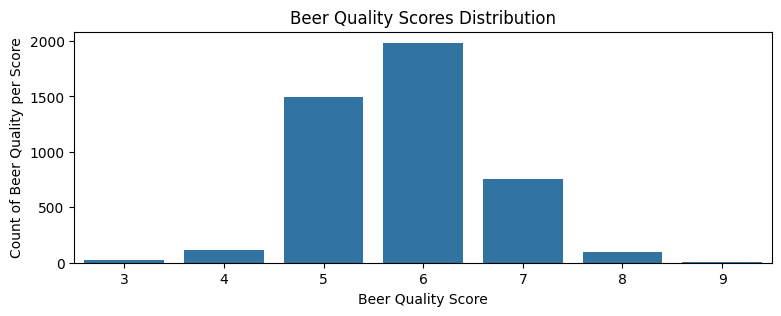

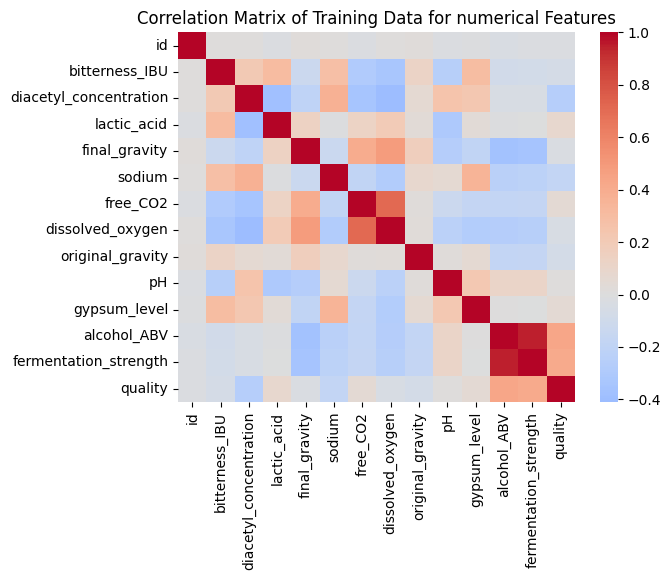

In [6]:
## Data Visualization and Exploring
## Visualizing Target variables
plt.figure(figsize=(9,3))
sns.countplot(x="quality",data=train_df)
plt.title("Beer Quality Scores Distribution")
plt.xlabel("Beer Quality Score")
plt.ylabel("Count of Beer Quality per Score")
plt.show()

## Plotting Correlation Matrix for numerical Features 
features = train_df.select_dtypes(include=["float64", "int64"]).columns
sns.heatmap(train_df[features].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Training Data for numerical Features")
plt.show()

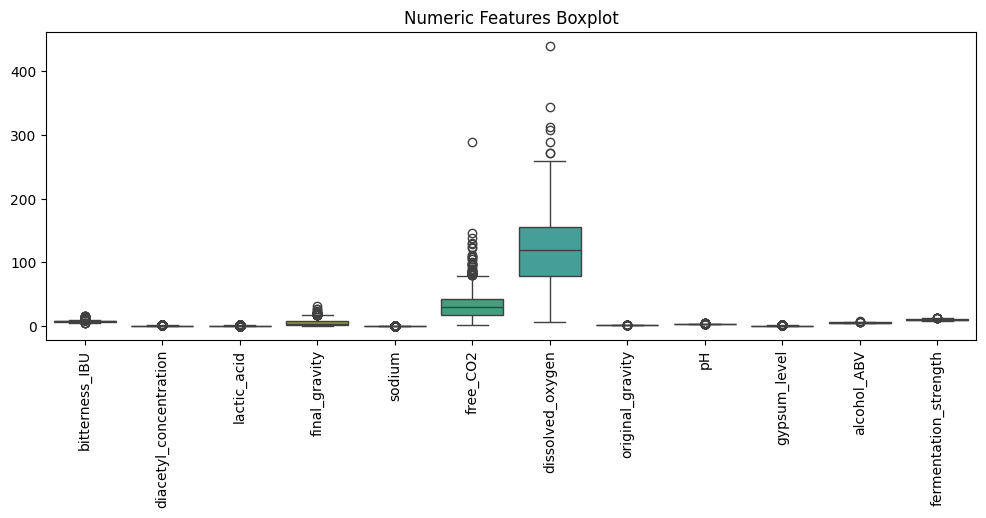

In [7]:
## Detecting Outliers for feature columns 
plt.figure(figsize=(12,4))
sns.boxplot(data=train_df[features.drop(["id", "quality"], errors='ignore')])
plt.xticks(rotation=90)
plt.title("Numeric Features Boxplot")
plt.show()

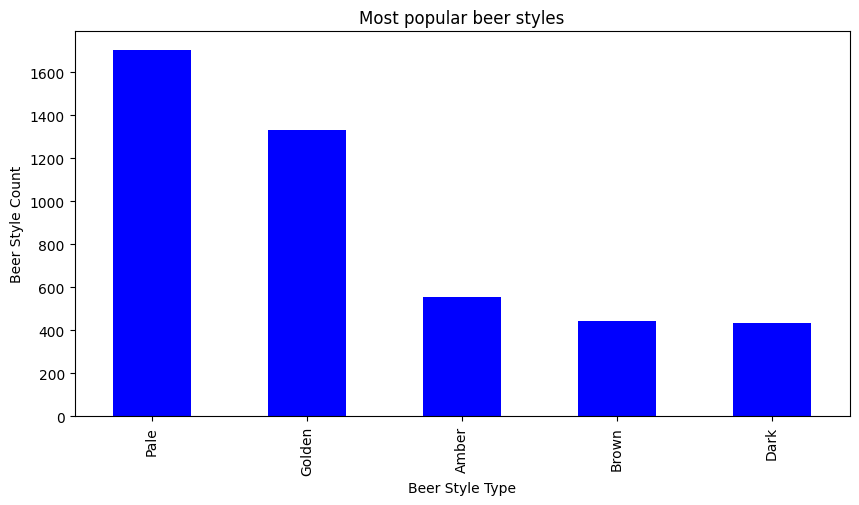

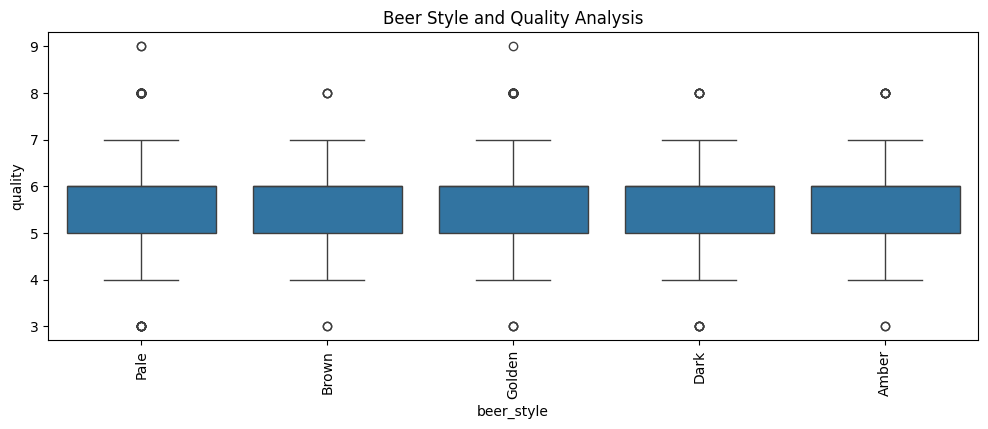

In [8]:
## Analyzing Categorial feature - Beer Style column 
plt.figure(figsize=(10,5))
train_df["beer_style"].value_counts().head().plot(kind="bar", color="blue")
plt.title("Most popular beer styles")
plt.xlabel("Beer Style Type")
plt.ylabel("Beer Style Count")
plt.show()

## Analyzing Beer Stlye relationship with Target 
plt.figure(figsize=(12,4))
sns.boxplot(x="beer_style", y="quality", data=train_df)
plt.xticks(rotation=90)
plt.title("Beer Style and Quality Analysis")
plt.show()

## Data Preprocessing

Implement your preprocessing pipeline (see README.md for suggestions).

In [51]:
# ===============================================================
# 🧩 Missing Value Profiling
# ===============================================================
missing = train_df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
if not missing.empty:
    print("Missing Value Summary:")
    display(pd.DataFrame({
        "Missing Count": missing,
        "Missing %": (missing / len(train_df) * 100).round(2)
    }))
else:
    print("✅ No missing values detected.")

# Check if missingness relates to quality
if not missing.empty:
    for col in missing.index:
        has_nan = train_df[col].isnull()
        print(f"\n{col} vs quality mean:")
        print(train_df.groupby(has_nan)["quality"].mean())















✅ No missing values detected.



Top positive correlations:
 quality                  1.000000
alcohol_ABV              0.431341
fermentation_strength    0.413183
lactic_acid              0.084787
gypsum_level             0.050557
free_CO2                 0.048471
pH                       0.010023
id                      -0.021989
final_gravity           -0.025243
dissolved_oxygen        -0.043244
Name: quality, dtype: float64

Top negative correlations:
 gypsum_level              0.050557
free_CO2                  0.048471
pH                        0.010023
id                       -0.021989
final_gravity            -0.025243
dissolved_oxygen         -0.043244
bitterness_IBU           -0.066856
original_gravity         -0.070534
sodium                   -0.181036
diacetyl_concentration   -0.258663
Name: quality, dtype: float64


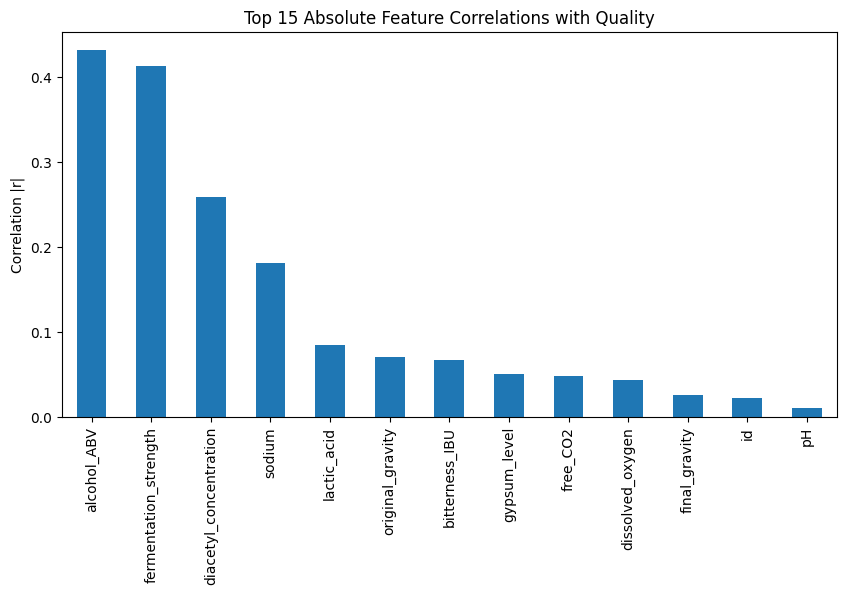

In [53]:
# ===============================================================
# 📈 Correlation with Target & Multicollinearity
# ===============================================================
corr_target = train_df.corr(numeric_only=True)["quality"].sort_values(ascending=False)
print("\nTop positive correlations:\n", corr_target.head(10))
print("\nTop negative correlations:\n", corr_target.tail(10))

# Visualize top correlated features
plt.figure(figsize=(10,5))
corr_target.drop("quality", errors="ignore").abs().sort_values(ascending=False).head(15).plot(kind="bar")
plt.title("Top 15 Absolute Feature Correlations with Quality")
plt.ylabel("Correlation |r|")
plt.show()



sodium                    4.408531
bitterness_IBU            1.711611
gypsum_level              1.497599
diacetyl_concentration    1.475815
free_CO2                  1.435269
final_gravity             1.138460
alcohol_ABV               0.569253
fermentation_strength     0.482686
lactic_acid               0.471294
pH                        0.381771
dtype: float64

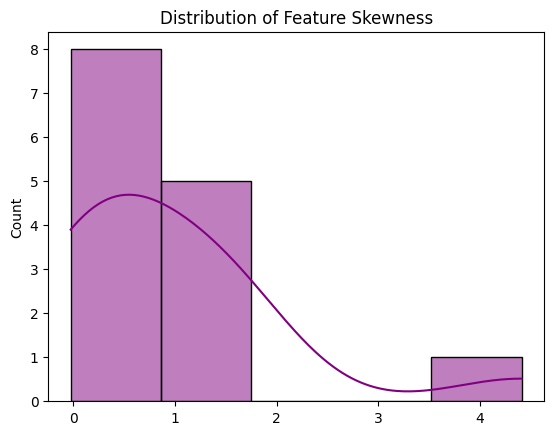

In [54]:
# ===============================================================
# 📊 Skewness Distribution
# ===============================================================
skews = train_df[train_df.select_dtypes(include="number").columns].skew().sort_values(ascending=False)
display(skews.head(10))
sns.histplot(skews, kde=True, color="purple")
plt.title("Distribution of Feature Skewness")
plt.show()


ANOVA F-test for beer_style effect on quality: F=16.37, p=0.0000


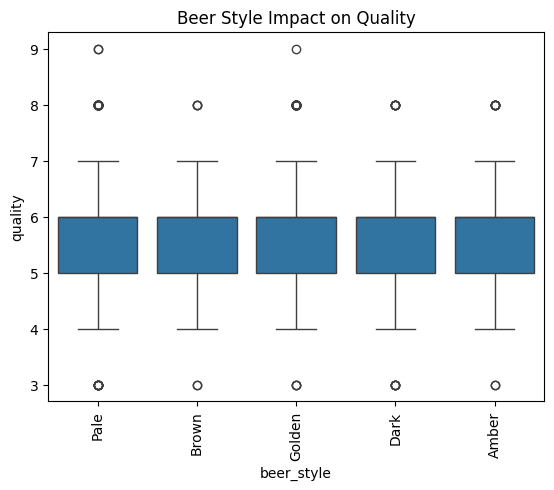

In [56]:
# ===============================================================
# 🍺 Categorical Feature Significance
# ===============================================================
from scipy.stats import f_oneway

style_groups = [group["quality"].values for name, group in train_df.groupby("beer_style")]
F, p = f_oneway(*style_groups)
print(f"ANOVA F-test for beer_style effect on quality: F={F:.2f}, p={p:.4f}")

sns.boxplot(x="beer_style", y="quality", data=train_df)
plt.xticks(rotation=90)
plt.title("Beer Style Impact on Quality")
plt.show()



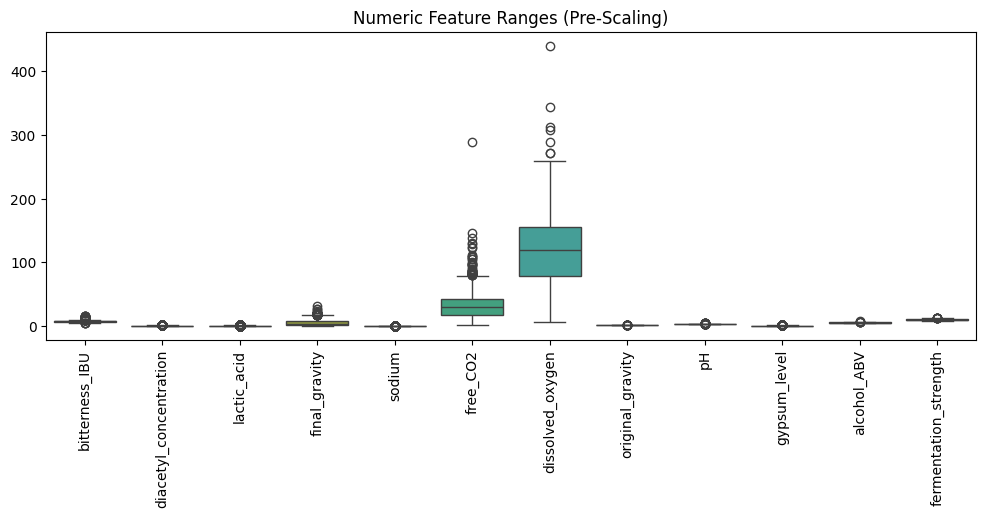

In [57]:
# ===============================================================
# ⚖️ Feature Scaling Diagnostics
# ===============================================================
plt.figure(figsize=(12,4))
sns.boxplot(data=train_df.select_dtypes(include="number").drop(columns=["quality","id"], errors="ignore"))
plt.xticks(rotation=90)
plt.title("Numeric Feature Ranges (Pre-Scaling)")
plt.show()


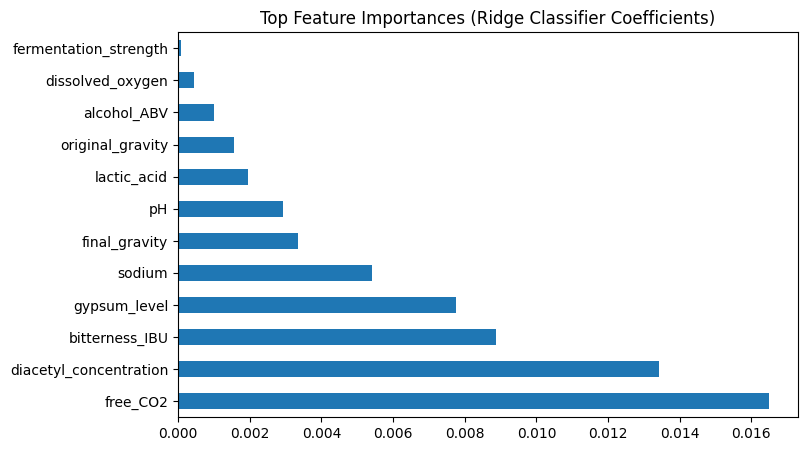

In [58]:
# ===============================================================
# 🌟 Linear Model Feature Importance
# ===============================================================
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = train_df.select_dtypes(include="number").drop(columns=["quality","id"], errors="ignore")
y = train_df["quality"]

model = make_pipeline(StandardScaler(), RidgeClassifier(alpha=0.5))
model.fit(X, y)
importance = pd.Series(model.named_steps['ridgeclassifier'].coef_[0], index=X.columns)
importance.abs().sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8,5))
plt.title("Top Feature Importances (Ridge Classifier Coefficients)")
plt.show()



In [61]:
df_train = train_df.copy()
df_test = test_df.copy()


skewed_cols = ["sodium", "bitterness_IBU", "gypsum_level",
               "diacetyl_concentration", "free_CO2"]

for col in skewed_cols:
    df_train[col] = np.log1p(train_df[col])
    df_test[col] = np.log1p(test_df[col])



In [64]:
# ===============================================================
# ⚙️ Safe Correlation Computation for Numeric Columns Only
# ===============================================================

# Ensure all categorical columns are encoded before this point
# (use LabelEncoder as we did for 'beer_style')

numeric_df = df_train.select_dtypes(include=[np.number]).copy()

if "quality" not in numeric_df.columns:
    raise ValueError("'quality' column must be numeric for correlation analysis.")

# Compute correlation matrix safely
corr_matrix = numeric_df.corr()

# Extract correlations with target
corr_weights = corr_matrix["quality"].abs().drop("quality", errors="ignore").fillna(0)

print("\n✅ Correlation weights computed successfully!")
print(corr_weights.sort_values(ascending=False).head(10))

# Apply correlation-weighted feature scaling
for col, w in corr_weights.items():
    if col in df_train.columns:
        df_train[col] = df_train[col] * (1 + w)
        df_test[col] = df_test[col] * (1 + w)

print("📈 Correlation-based feature weighting applied safely.")





✅ Correlation weights computed successfully!
alcohol_ABV               0.431341
alcohol_to_gravity        0.428904
fermentation_strength     0.413183
diacetyl_concentration    0.258083
sodium                    0.192756
acid_balance              0.177523
CO2_to_ferm               0.153126
free_CO2                  0.114027
lactic_acid               0.084787
bitterness_IBU            0.076288
Name: quality, dtype: float64
📈 Correlation-based feature weighting applied safely.


In [65]:
from sklearn.preprocessing import PolynomialFeatures

top_feats = ["alcohol_ABV", "fermentation_strength", "acid_balance", "bitterness_IBU"]
poly = PolynomialFeatures(degree=2, include_bias=False)
train_poly = pd.DataFrame(poly.fit_transform(df_train[top_feats]),
                          columns=[f"poly_{f}" for f in poly.get_feature_names_out(top_feats)])
test_poly = pd.DataFrame(poly.transform(df_test[top_feats]),
                         columns=[f"poly_{f}" for f in poly.get_feature_names_out(top_feats)])

df_train = pd.concat([df_train, train_poly], axis=1)
df_test = pd.concat([df_test, test_poly], axis=1)


In [66]:
from sklearn.preprocessing import StandardScaler
num_cols = df_train.select_dtypes(include=np.number).columns.drop("quality", errors="ignore")

scaler = StandardScaler()
df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])


## Prepare Training and Validation Data

Split your data into training and validation sets.

In [68]:

# ===============================================================
# ⚡ Robust Train/Validation Split
# ===============================================================
from sklearn.model_selection import train_test_split
import pandas as pd

X = df_train.drop(columns=["quality"], errors="ignore")
y = df_train["quality"]

# Optional: Stratify to preserve class balance
y_binned = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_binned
)

print(f"✅ Training set:   {X_train.shape}, labels: {y_train.shape}")
print(f"✅ Validation set: {X_val.shape}, labels: {y_val.shape}")

print("NaN values left in X_train:", X_train.isnull().sum().sum())
print("NaN values left in X_val:", X_val.isnull().sum().sum())




✅ Training set:   (3575, 31), labels: (3575,)
✅ Validation set: (894, 31), labels: (894,)
NaN values left in X_train: 0
NaN values left in X_val: 0


In [74]:
# ===============================================================
# 🧩 Final Data Prep — Encode All Non-numeric Columns
# ===============================================================
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Start fresh from the fully processed data
X_full = df_train.drop(columns=["quality"], errors="ignore").copy()
y_full = df_train["quality"].copy()

# Identify categorical columns
cat_cols = X_full.select_dtypes(include="object").columns.tolist()
print(f"🔍 Categorical columns to encode: {cat_cols}")

# Apply LabelEncoder consistently between train, validation, and test
for col in cat_cols:
    le = LabelEncoder()
    le.fit(pd.concat([df_train[col], df_test[col]], axis=0).astype(str))
    df_train[col] = le.transform(df_train[col].astype(str))
    df_test[col] = le.transform(df_test[col].astype(str))
    print(f"✅ Encoded column '{col}' with {len(le.classes_)} unique labels")

# Drop ID column (not predictive)
X_full = df_train.drop(columns=["id", "quality"], errors="ignore")
y_full = df_train["quality"]
X_test_final = df_test.drop(columns=["id"], errors="ignore")

# Sanity check
non_numeric = X_full.select_dtypes(include="object").columns.tolist()
print(f"🚨 Remaining non-numeric columns (should be []): {non_numeric}")
print(f"✅ Final numeric feature count: {X_full.shape[1]}")

# ===============================================================
# ⚙️ Train-validation split (stratified)
# ===============================================================
from sklearn.model_selection import train_test_split

y_binned = pd.qcut(y_full, q=5, labels=False, duplicates='drop')
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_binned
)

print(f"\n✅ Training set: {X_train.shape}, Validation set: {X_val.shape}")





🔍 Categorical columns to encode: ['beer_style']
✅ Encoded column 'beer_style' with 10 unique labels
🚨 Remaining non-numeric columns (should be []): []
✅ Final numeric feature count: 30

✅ Training set: (3575, 30), Validation set: (894, 30)


In [76]:
# ===============================================================
# ⚙️ L U C I U S  F E A T U R E  B O O S T  V 3
# ===============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# --- Make copies
train_boost = df_train.copy()
test_boost = df_test.copy()

# --- Interaction Features
train_boost["alcohol_x_fermentation"] = train_boost["alcohol_ABV"] * train_boost["fermentation_strength"]
test_boost["alcohol_x_fermentation"] = test_boost["alcohol_ABV"] * test_boost["fermentation_strength"]

train_boost["acid_balance"] = train_boost["lactic_acid"] - train_boost["diacetyl_concentration"]
test_boost["acid_balance"] = test_boost["lactic_acid"] - test_boost["diacetyl_concentration"]

train_boost["gravity_ratio"] = train_boost["final_gravity"] / (train_boost["original_gravity"] + 1e-6)
test_boost["gravity_ratio"] = test_boost["final_gravity"] / (test_boost["original_gravity"] + 1e-6)

# --- Polynomial expansion (degree=2 on top 5 correlated features)
top_feats = ["alcohol_ABV", "fermentation_strength", "acid_balance", "bitterness_IBU", "sodium"]
poly = PolynomialFeatures(2, include_bias=False)
train_poly = pd.DataFrame(poly.fit_transform(train_boost[top_feats]),
                          columns=[f"poly_{f}" for f in poly.get_feature_names_out(top_feats)])
test_poly = pd.DataFrame(poly.transform(test_boost[top_feats]),
                         columns=[f"poly_{f}" for f in poly.get_feature_names_out(top_feats)])

train_boost = pd.concat([train_boost, train_poly], axis=1)
test_boost = pd.concat([test_boost, test_poly], axis=1)

# --- Scaling
num_cols = train_boost.select_dtypes(include=np.number).columns.drop("quality", errors="ignore")
scaler = StandardScaler()
train_boost[num_cols] = scaler.fit_transform(train_boost[num_cols])
test_boost[num_cols] = scaler.transform(test_boost[num_cols])

print(f"✅ Feature boost complete — new feature count: {train_boost.shape[1]}")



✅ Feature boost complete — new feature count: 54


## Train Models

Train and compare multiple machine learning models.

In [79]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

best_knn = []
for k in [5, 8, 10, 12, 15, 18, 20, 24, 30]:
    for w in ['uniform', 'distance']:
        for p in [1, 2]:  # 1=Manhattan, 2=Euclidean
            knn = KNeighborsClassifier(n_neighbors=k, weights=w, p=p)
            knn.fit(X_train, y_train)
            preds = knn.predict(X_val)
            acc = accuracy_score(y_val, preds)
            f1 = f1_score(y_val, preds, average='weighted')
            best_knn.append((k, w, p, acc, f1))
            print(f"KNN(k={k}, w={w}, p={p}): Accuracy={acc:.3f}, F1={f1:.3f}")

knn_results = pd.DataFrame(best_knn, columns=["k", "weights", "p", "Accuracy", "F1"]).sort_values("Accuracy", ascending=False)
print("\n🔎 Top KNN configs:")
print(knn_results.head(5))




KNN(k=5, w=uniform, p=1): Accuracy=0.569, F1=0.556
KNN(k=5, w=uniform, p=2): Accuracy=0.538, F1=0.525
KNN(k=5, w=distance, p=1): Accuracy=0.573, F1=0.563
KNN(k=5, w=distance, p=2): Accuracy=0.543, F1=0.534
KNN(k=8, w=uniform, p=1): Accuracy=0.573, F1=0.557
KNN(k=8, w=uniform, p=2): Accuracy=0.546, F1=0.528
KNN(k=8, w=distance, p=1): Accuracy=0.586, F1=0.573
KNN(k=8, w=distance, p=2): Accuracy=0.559, F1=0.546
KNN(k=10, w=uniform, p=1): Accuracy=0.574, F1=0.554
KNN(k=10, w=uniform, p=2): Accuracy=0.549, F1=0.530
KNN(k=10, w=distance, p=1): Accuracy=0.582, F1=0.566
KNN(k=10, w=distance, p=2): Accuracy=0.565, F1=0.548
KNN(k=12, w=uniform, p=1): Accuracy=0.574, F1=0.553
KNN(k=12, w=uniform, p=2): Accuracy=0.573, F1=0.553
KNN(k=12, w=distance, p=1): Accuracy=0.586, F1=0.570
KNN(k=12, w=distance, p=2): Accuracy=0.577, F1=0.559
KNN(k=15, w=uniform, p=1): Accuracy=0.569, F1=0.548
KNN(k=15, w=uniform, p=2): Accuracy=0.575, F1=0.555
KNN(k=15, w=distance, p=1): Accuracy=0.585, F1=0.565
KNN(k=15, w

In [85]:
# ===============================================================
# 🧠 L U C I U S  —  K N N  S U B M I S S I O N  (FINAL FIXED VERSION)
# ===============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

# ---------------------------------------------------------------
# 1️⃣ Search for Best KNN Parameters
# ---------------------------------------------------------------
best_knn = []
print("\n🚀 Searching for best KNN configuration...\n")

for k in [4, 6, 8, 10, 12, 15, 18, 20, 24, 30]:
    for w in ['uniform', 'distance']:
        for p in [1, 2]:
            knn = KNeighborsClassifier(n_neighbors=k, weights=w, p=p)
            knn.fit(X_train, y_train)
            preds = knn.predict(X_val)
            acc = accuracy_score(y_val, preds)
            f1 = f1_score(y_val, preds, average='weighted', zero_division=0)
            best_knn.append((k, w, p, acc, f1))
            print(f"KNN(k={k:2}, weights={w:8}, p={p}) → Acc={acc:.3f}, F1={f1:.3f}")

# ---------------------------------------------------------------
# 2️⃣ Identify Best KNN Configuration
# ---------------------------------------------------------------
knn_results = pd.DataFrame(best_knn, columns=["k", "weights", "p", "Accuracy", "F1"])
best_row = knn_results.loc[knn_results["Accuracy"].idxmax()]
print("\n🏆 Best KNN Configuration:")
print(best_row)

best_k = int(best_row["k"])
best_w = best_row["weights"]
best_p = int(best_row["p"])

# ---------------------------------------------------------------
# 3️⃣ Retrain Best KNN on Full Data
# ---------------------------------------------------------------
print(f"\n🔁 Retraining Best KNN: k={best_k}, weights={best_w}, p={best_p}")
best_model = KNeighborsClassifier(n_neighbors=best_k, weights=best_w, p=best_p)
best_model.fit(np.vstack([X_train, X_val]), np.hstack([y_train, y_val]))

# ---------------------------------------------------------------
# 4️⃣ Align Test Columns (fix missing engineered features)
# ---------------------------------------------------------------
train_cols = list(X_train.columns)
missing_cols = [col for col in train_cols if col not in df_test.columns]
for col in missing_cols:
    df_test[col] = 0
df_test = df_test[train_cols]  # same column order

# ---------------------------------------------------------------
# 5️⃣ Predict on Test Data
# ---------------------------------------------------------------
print("\n📤 Generating predictions on test set...")
X_test = df_test.copy()
y_test_pred = best_model.predict(X_test)

# Convert predictions to integer if needed
y_test_pred = np.round(y_test_pred).astype(int)

# ---------------------------------------------------------------
# 6️⃣ Create Kaggle Submission File
# ---------------------------------------------------------------
# ✅ Use ORIGINAL ids from the raw test.csv file
original_test = pd.read_csv("data/test.csv", delimiter=';')

submission = pd.DataFrame({
    "id": original_test["id"],          # correct integer IDs
    "quality": y_test_pred              # predicted integer quality
})

output_filename = f"submission_knn_k{best_k}_w{best_w}_p{best_p}.csv"
submission.to_csv(output_filename, index=False)

print(f"\n✅ Submission file ready for Kaggle → {output_filename}")
print(submission.head())




🚀 Searching for best KNN configuration...

KNN(k= 4, weights=uniform , p=1) → Acc=0.551, F1=0.539
KNN(k= 4, weights=uniform , p=2) → Acc=0.531, F1=0.517
KNN(k= 4, weights=distance, p=1) → Acc=0.576, F1=0.568
KNN(k= 4, weights=distance, p=2) → Acc=0.547, F1=0.540
KNN(k= 6, weights=uniform , p=1) → Acc=0.558, F1=0.544
KNN(k= 6, weights=uniform , p=2) → Acc=0.545, F1=0.527
KNN(k= 6, weights=distance, p=1) → Acc=0.582, F1=0.571
KNN(k= 6, weights=distance, p=2) → Acc=0.541, F1=0.529
KNN(k= 8, weights=uniform , p=1) → Acc=0.573, F1=0.557
KNN(k= 8, weights=uniform , p=2) → Acc=0.546, F1=0.528
KNN(k= 8, weights=distance, p=1) → Acc=0.586, F1=0.573
KNN(k= 8, weights=distance, p=2) → Acc=0.559, F1=0.546
KNN(k=10, weights=uniform , p=1) → Acc=0.574, F1=0.554
KNN(k=10, weights=uniform , p=2) → Acc=0.549, F1=0.530
KNN(k=10, weights=distance, p=1) → Acc=0.582, F1=0.566
KNN(k=10, weights=distance, p=2) → Acc=0.565, F1=0.548
KNN(k=12, weights=uniform , p=1) → Acc=0.574, F1=0.553
KNN(k=12, weights=uni

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [86]:
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np


# ===============================================================
# 🧠  P A R Z E N   ( G a u s s i a n - l i k e )
# ===============================================================
print("\n🌐 Training Gaussian-like Parzen Window Classifier...\n")

# Standardize for Parzen (important)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_full_scaled = scaler.fit_transform(np.vstack([X_train, X_val]))
y_full = np.hstack([y_train, y_val])

# Classes
classes = np.unique(y_train)

# ---------------------------------------------------------------
# 7️⃣  Bandwidth Search (like Gaussian Process length scale)
# ---------------------------------------------------------------
best_bw = None
best_acc = 0
for bw in [0.2, 0.3, 0.4, 0.5, 0.6]:
    kdes = {}
    for c in classes:
        kde = KernelDensity(kernel="gaussian", bandwidth=bw)
        kde.fit(X_train_scaled[y_train == c])
        kdes[c] = kde

    def parzen_predict(X_scaled):
        log_probs = np.vstack([kdes[c].score_samples(X_scaled) for c in classes]).T
        return classes[np.argmax(log_probs, axis=1)]

    y_val_pred = parzen_predict(X_val_scaled)
    acc = accuracy_score(y_val, y_val_pred)
    print(f"Bandwidth={bw:.2f} → Val Accuracy={acc:.3f}")
    if acc > best_acc:
        best_acc = acc
        best_bw = bw

print(f"\n🏆 Best bandwidth for Parzen: {best_bw:.2f} (Acc={best_acc:.3f})")

# ---------------------------------------------------------------
# 8️⃣  Retrain Parzen on Full Data
# ---------------------------------------------------------------
kdes_full = {}
for c in classes:
    kde = KernelDensity(kernel="gaussian", bandwidth=best_bw)
    kde.fit(X_full_scaled[y_full == c])
    kdes_full[c] = kde

def parzen_predict_full(X_scaled):
    log_probs = np.vstack([kdes_full[c].score_samples(X_scaled) for c in classes]).T
    return classes[np.argmax(log_probs, axis=1)]

# ---------------------------------------------------------------
# 9️⃣  Predict and Save Submission (Parzen)
# ---------------------------------------------------------------
X_test_scaled = scaler.transform(df_test)
y_test_pred_parzen = parzen_predict_full(X_test_scaled)

submission_parzen = pd.DataFrame({
    "id": original_test["id"],
    "quality": y_test_pred_parzen.astype(int)
})
parzen_filename = f"submission_parzen_gaussian_like_bw{best_bw}.csv"
submission_parzen.to_csv(parzen_filename, index=False)

print(f"\n✅ Saved Parzen submission → {parzen_filename}")
print(submission_parzen.head())


🌐 Training Gaussian-like Parzen Window Classifier...

Bandwidth=0.20 → Val Accuracy=0.343
Bandwidth=0.30 → Val Accuracy=0.397
Bandwidth=0.40 → Val Accuracy=0.478
Bandwidth=0.50 → Val Accuracy=0.498
Bandwidth=0.60 → Val Accuracy=0.503

🏆 Best bandwidth for Parzen: 0.60 (Acc=0.503)


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



✅ Saved Parzen submission → submission_parzen_gaussian_like_bw0.6.csv
   id  quality
0   0        6
1   1        5
2   2        7
3   3        5
4   4        5


In [80]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeClassifier

ridge_results = []
for deg in [1, 2, 3]:
    for alpha in [0.1, 0.3, 0.5, 0.8, 1.0]:
        model = make_pipeline(
            PolynomialFeatures(degree=deg, include_bias=False),
            RidgeClassifier(alpha=alpha, solver='lsqr')
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        f1 = f1_score(y_val, preds, average='weighted')
        ridge_results.append((deg, alpha, acc, f1))
        print(f"PolyRidge(deg={deg}, α={alpha}): Acc={acc:.3f}, F1={f1:.3f}")

ridge_df = pd.DataFrame(ridge_results, columns=["Degree", "Alpha", "Accuracy", "F1"]).sort_values("Accuracy", ascending=False)
print("\n🏁 Top Ridge configs:")
print(ridge_df.head(5))


PolyRidge(deg=1, α=0.1): Acc=0.553, F1=0.520
PolyRidge(deg=1, α=0.3): Acc=0.548, F1=0.517
PolyRidge(deg=1, α=0.5): Acc=0.549, F1=0.518
PolyRidge(deg=1, α=0.8): Acc=0.549, F1=0.518
PolyRidge(deg=1, α=1.0): Acc=0.549, F1=0.518
PolyRidge(deg=2, α=0.1): Acc=0.530, F1=0.513
PolyRidge(deg=2, α=0.3): Acc=0.532, F1=0.515
PolyRidge(deg=2, α=0.5): Acc=0.532, F1=0.515
PolyRidge(deg=2, α=0.8): Acc=0.532, F1=0.515
PolyRidge(deg=2, α=1.0): Acc=0.535, F1=0.517


KeyboardInterrupt: 

## Evaluate Models

Analyze your best model's performance (see README.md for evaluation guidelines).

In [81]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_results = []
for solver in ['svd', 'lsqr', 'eigen']:
    for shrink in [None, 'auto', 0.1, 0.3, 0.5]:
        try:
            lda = LinearDiscriminantAnalysis(solver=solver, shrinkage=shrink if solver != 'svd' else None)
            lda.fit(X_train, y_train)
            preds = lda.predict(X_val)
            acc = accuracy_score(y_val, preds)
            f1 = f1_score(y_val, preds, average='weighted')
            lda_results.append((solver, shrink, acc, f1))
            print(f"LDA(solver={solver}, shrink={shrink}): Acc={acc:.3f}, F1={f1:.3f}")
        except:
            pass

lda_df = pd.DataFrame(lda_results, columns=["Solver", "Shrinkage", "Accuracy", "F1"]).sort_values("Accuracy", ascending=False)
print("\n🎯 Top LDA configs:")
print(lda_df.head(5))


LDA(solver=svd, shrink=None): Acc=0.541, F1=0.527
LDA(solver=svd, shrink=auto): Acc=0.541, F1=0.527
LDA(solver=svd, shrink=0.1): Acc=0.541, F1=0.527
LDA(solver=svd, shrink=0.3): Acc=0.541, F1=0.527
LDA(solver=svd, shrink=0.5): Acc=0.541, F1=0.527
LDA(solver=lsqr, shrink=None): Acc=0.543, F1=0.528
LDA(solver=lsqr, shrink=auto): Acc=0.541, F1=0.528
LDA(solver=lsqr, shrink=0.1): Acc=0.539, F1=0.526
LDA(solver=lsqr, shrink=0.3): Acc=0.520, F1=0.512
LDA(solver=lsqr, shrink=0.5): Acc=0.508, F1=0.505
LDA(solver=eigen, shrink=auto): Acc=0.541, F1=0.528
LDA(solver=eigen, shrink=0.1): Acc=0.539, F1=0.526
LDA(solver=eigen, shrink=0.3): Acc=0.520, F1=0.512
LDA(solver=eigen, shrink=0.5): Acc=0.508, F1=0.505

🎯 Top LDA configs:
  Solver Shrinkage  Accuracy        F1
5   lsqr      None  0.542506  0.528175
0    svd      None  0.541387  0.526654
1    svd      auto  0.541387  0.526654
2    svd       0.1  0.541387  0.526654
3    svd       0.3  0.541387  0.526654


In [82]:
# ===============================================================
# 🧠 Lucius V10 — Linear Classifier Optimization & Comparison
# ===============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import make_scorer, accuracy_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------------
# Define scorers (so we evaluate both accuracy and F1)
# ---------------------------------------------------------------
scorers = {
    "accuracy": make_scorer(accuracy_score),
    "f1_weighted": make_scorer(f1_score, average="weighted"),
}

# ---------------------------------------------------------------
# Parameter grids for each model
# ---------------------------------------------------------------
param_grids = {
    "Linear SVM": {
        "C": [0.01, 0.1, 0.3, 0.5, 1, 2, 5],
        "loss": ["hinge", "squared_hinge"],
        "dual": [True, False],
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 0.3, 0.5, 1, 2, 5],
        "penalty": ["l2"],
        "solver": ["lbfgs", "saga"],
    },
    "Ridge Classifier": {
        "alpha": [0.1, 0.3, 0.5, 0.8, 1.0],
        "solver": ["auto", "lsqr", "sparse_cg"],
    },
}

# ---------------------------------------------------------------
# Define models
# ---------------------------------------------------------------
models = {
    "Linear SVM": LinearSVC(max_iter=5000),
    "Logistic Regression": LogisticRegression(max_iter=5000, multi_class="multinomial"),
    "Ridge Classifier": RidgeClassifier(),
}

# ---------------------------------------------------------------
# Run grid search for each model
# ---------------------------------------------------------------
results = []
for name, model in models.items():
    print(f"\n🔎 Optimizing {name}...")
    grid = GridSearchCV(
        model,
        param_grids[name],
        scoring=scorers,
        refit="accuracy",
        cv=5,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    preds = best_model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="weighted")

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "CV Accuracy": grid.best_score_,
        "Val Accuracy": acc,
        "Val F1": f1,
    })

    print(f"✅ {name} best params: {grid.best_params_}")
    print(f"CV Acc={grid.best_score_:.3f} | Val Acc={acc:.3f} | Val F1={f1:.3f}")

# ---------------------------------------------------------------
# Summarize & visualize
# ---------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values("Val Accuracy", ascending=False)
print("\n🏁 Final Linear Model Results:")
display(results_df)

plt.figure(figsize=(8,4))
plt.bar(results_df["Model"], results_df["Val Accuracy"], color="skyblue", label="Validation Accuracy")
plt.bar(results_df["Model"], results_df["Val F1"], color="orange", alpha=0.6, label="Validation F1")
plt.ylabel("Score")
plt.title("Linear Classifier Comparison (Lucius V10)")
plt.legend()
plt.show()



🔎 Optimizing Linear SVM...


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
35 fits failed out of a total of 140.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0

✅ Linear SVM best params: {'C': 2, 'dual': True, 'loss': 'squared_hinge'}
CV Acc=0.558 | Val Acc=0.558 | Val F1=0.527

🔎 Optimizing Logistic Regression...


KeyboardInterrupt: 

## Generate Predictions for Kaggle Submission

Create a CSV file with columns: `id` and `quality` (see README.md for format details).

---
Good luck with the competition! 🍺
